# Comprehensive EDA for DocFusion

This notebook explores three receipt sources used to inform the extraction and tampering pipeline:

- **SROIE 2019**: real scanned retail receipts with entity annotations for company, date, address, and total.
- **Find-It-Again / challenge dummy data**: the local synthetic training subset in `dummy_data/train/`, which mirrors the task schema used by the challenge harness.
- **CORD samples**: curated real-world receipt images used here as an unlabeled comparison set for OCR and visual characteristics.

`SROIE` and `CORD` are external datasets and must be downloaded separately. This notebook intentionally reads them from `/tmp/` so the repository stays clean and does not vendor the datasets.


In [1]:
import json
import os
import re
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageChops, ImageStat

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
NOTEBOOK_DIR = os.path.join(ROOT, 'notebooks')
SROIE_IMG_DIR = '/tmp/sroie/SROIE2019/train/img'
SROIE_ENT_DIR = '/tmp/sroie/SROIE2019/train/entities'
CORD_DIR = '/tmp/cord_samples'
DUMMY_IMG_DIR = os.path.join(ROOT, 'dummy_data/train/images')
DUMMY_JSONL = os.path.join(ROOT, 'dummy_data/train/train.jsonl')

os.makedirs(NOTEBOOK_DIR, exist_ok=True)


def run_tesseract_tsv(path):
    raw = os.popen(f'tesseract "{path}" stdout --psm 6 tsv 2>/dev/null').read().splitlines()
    if not raw:
        return {'text': '', 'confidences': [], 'words': []}
    header = raw[0].split('	')
    idx = {name: i for i, name in enumerate(header)}
    rows = []
    for line in raw[1:]:
        parts = line.split('	')
        if len(parts) < len(header):
            parts += [''] * (len(header) - len(parts))
        text = parts[idx['text']].strip()
        try:
            conf = float(parts[idx['conf']]) if parts[idx['conf']] not in ('', '-1') else -1.0
        except ValueError:
            conf = -1.0
        if text and conf >= 0:
            rows.append((text, conf))
    return {
        'text': ' '.join(word for word, _ in rows),
        'confidences': [conf for _, conf in rows],
        'words': [word for word, _ in rows],
    }


def ela_mean(path, quality=90):
    tmp_path = os.path.join(NOTEBOOK_DIR, '_eda_temp.jpg')
    with Image.open(path) as im:
        rgb = im.convert('RGB')
        rgb.save(tmp_path, 'JPEG', quality=quality)
        with Image.open(tmp_path) as recompressed:
            diff = ImageChops.difference(rgb, recompressed)
            stat = ImageStat.Stat(diff)
            return float(np.mean(stat.mean))


def year_from_date(text):
    tokens = [t for t in re.split(r'[^0-9]+', text) if t]
    for token in (tokens[:1] + tokens[-1:]):
        if len(token) == 4 and token.startswith('20'):
            return int(token)
    if tokens and len(tokens[-1]) == 2:
        return 2000 + int(tokens[-1])
    return None


Imports and helper functions prepared.


## 1. Dataset Overview

The first pass checks how many images are available per source, how large those files are on disk, and what the raw receipt images look like side by side.


Image counts
- SROIE: 626
- CORD: 20
- Find-It-Again dummy: 20

File size summary (KB)
- SROIE mean=553.5, median=347.3, min=57.8, max=3540.2
- CORD mean=1648.2, median=1289.4, min=259.7, max=5020.2
- Dummy mean=0.3, median=0.3, min=0.3, max=0.3


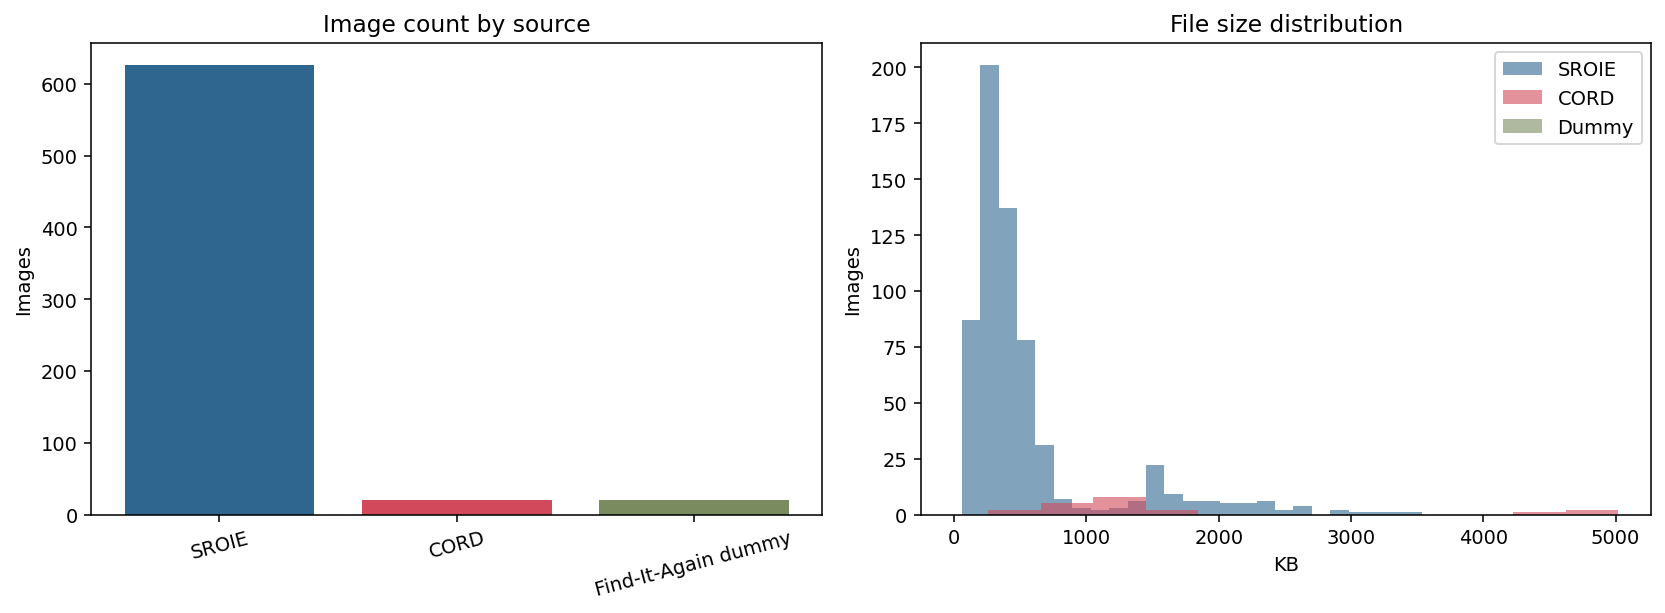

In [2]:
sroie_images = sorted(glob(os.path.join(SROIE_IMG_DIR, '*.jpg')))
cord_images = sorted(glob(os.path.join(CORD_DIR, '*.png')))
dummy_images = sorted(glob(os.path.join(DUMMY_IMG_DIR, '*.png')))

sroie_sizes = np.array([os.path.getsize(path) / 1024.0 for path in sroie_images])
cord_sizes = np.array([os.path.getsize(path) / 1024.0 for path in cord_images])
dummy_sizes = np.array([os.path.getsize(path) / 1024.0 for path in dummy_images])

print('SROIE images:', len(sroie_images))
print('CORD images:', len(cord_images))
print('Dummy images:', len(dummy_images))
print('SROIE mean size KB:', round(float(np.mean(sroie_sizes)), 2))
print('CORD mean size KB:', round(float(np.mean(cord_sizes)), 2))
print('Dummy mean size KB:', round(float(np.mean(dummy_sizes)), 2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(['SROIE', 'CORD', 'Dummy'], [len(sroie_images), len(cord_images), len(dummy_images)], color=['#2f6690', '#d1495b', '#7a8b5f'])
ax[0].set_title('Image count by source')
ax[0].set_ylabel('Images')
ax[1].hist(sroie_sizes, bins=25, alpha=0.6, label='SROIE', color='#2f6690')
ax[1].hist(cord_sizes, bins=12, alpha=0.6, label='CORD', color='#d1495b')
ax[1].hist(dummy_sizes, bins=12, alpha=0.6, label='Dummy', color='#7a8b5f')
ax[1].set_title('File size distribution')
ax[1].set_xlabel('KB')
ax[1].set_ylabel('Images')
ax[1].legend()
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_file_size_distribution.png'), dpi=140, bbox_inches='tight')
plt.show()


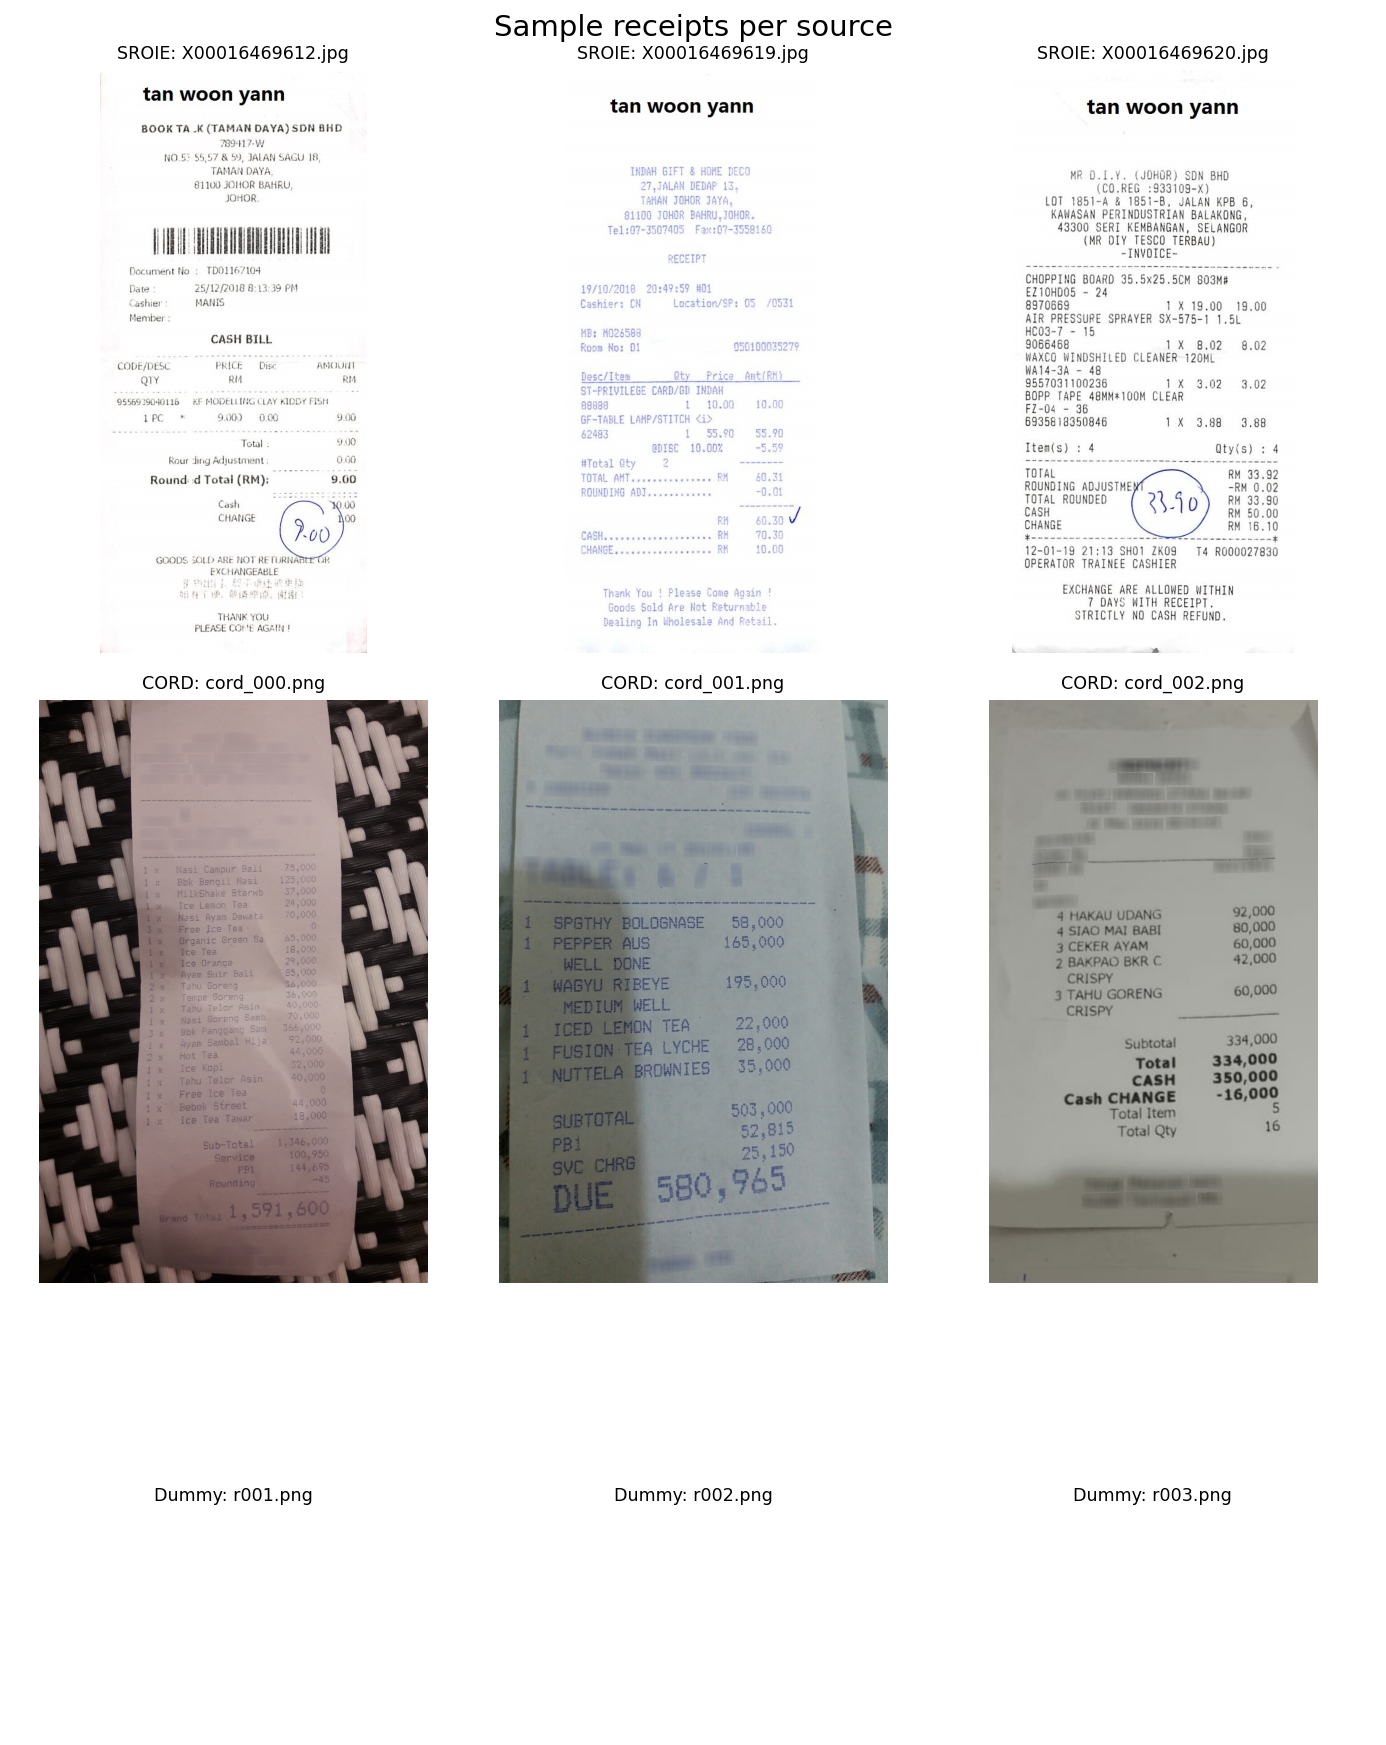

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(10, 14))
for row_idx, (label, paths) in enumerate([
    ('SROIE', sroie_images[:3]),
    ('CORD', cord_images[:3]),
    ('Dummy', dummy_images[:3]),
]):
    for col_idx, path in enumerate(paths):
        with Image.open(path) as im:
            axes[row_idx, col_idx].imshow(im)
        axes[row_idx, col_idx].set_title(f'{label}: {os.path.basename(path)}', fontsize=9)
        axes[row_idx, col_idx].axis('off')
fig.suptitle('Three sample receipts per source', fontsize=15)
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_dataset_samples.png'), dpi=140, bbox_inches='tight')
plt.show()


## 2. OCR Quality Analysis

Tesseract OCR is run on 10 SROIE receipts and 5 CORD receipts. The goal is to compare raw OCR confidence behavior and inspect representative text quality before building extraction heuristics.


OCR sample sizes
- SROIE receipts: 10
- CORD receipts: 5

Mean confidence summary
- SROIE mean=73.41, median=73.53
- CORD mean=47.39, median=43.93

OCR text examples
Example 1: X00016469612.jpg
tan woon yann BOOK TA -K (TAMAN DAYA) SDN BHD 7B 7-W NO.5: 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR. apts | WAM MUTANT Document Ho : TDO1167104 Date 25/12/2018 8:13:39 PH Cashier MANIS Member CASH BILL CODE/DESC : PRICE Dise AMOUHT Qiy Ri RM 955693040116 KF MODELLING Cay KIDDY FISH : 1 PC * 9.00) 0,00 9.00 Total : 9.00 Rour ding Adjustment 0.00 Round. :d Total (RM): 9.60 Cash yy 40.00 CHANGE 00 00 GOODS SOLD ARE NOT RETURNAP aK EXCHANGEABLE an Th, SORA TH THANK YOU PLEASE COME AGAIN t

Example 2: cord_000.png
Ml. ™ ‘K mM &£€ . “= — ~


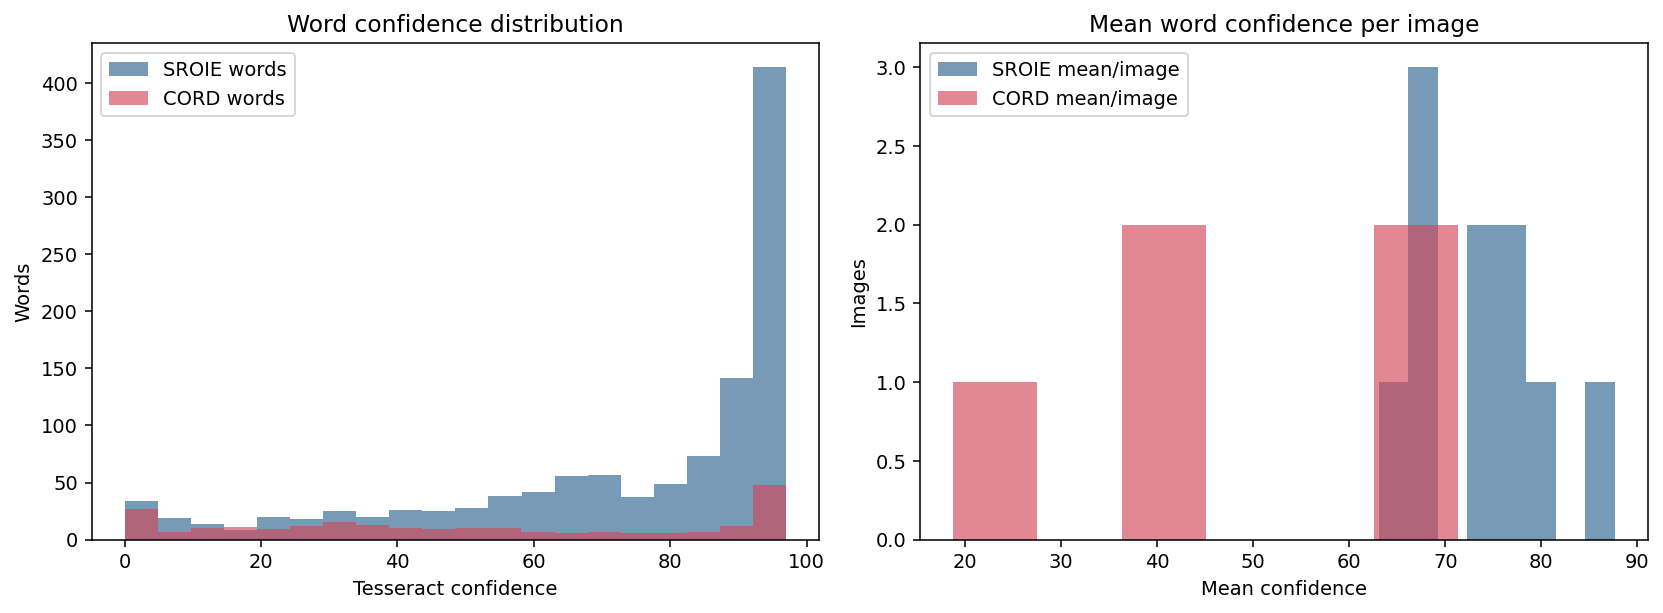

In [4]:
sroie_ocr = [(path, run_tesseract_tsv(path)) for path in sroie_images[:10]]
cord_ocr = [(path, run_tesseract_tsv(path)) for path in cord_images[:5]]

sroie_mean_conf = np.array([np.mean(item['confidences']) if item['confidences'] else np.nan for _, item in sroie_ocr])
cord_mean_conf = np.array([np.mean(item['confidences']) if item['confidences'] else np.nan for _, item in cord_ocr])
all_sroie_conf = np.array([conf for _, item in sroie_ocr for conf in item['confidences']])
all_cord_conf = np.array([conf for _, item in cord_ocr for conf in item['confidences']])

print('SROIE OCR mean confidence:', round(float(np.nanmean(sroie_mean_conf)), 2))
print('CORD OCR mean confidence:', round(float(np.nanmean(cord_mean_conf)), 2))
print('
SROIE example OCR:
', sroie_ocr[0][1]['text'][:900])
print('
CORD example OCR:
', cord_ocr[0][1]['text'][:900])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(all_sroie_conf, bins=20, alpha=0.65, label='SROIE words', color='#2f6690')
ax[0].hist(all_cord_conf, bins=20, alpha=0.65, label='CORD words', color='#d1495b')
ax[0].set_title('Word confidence distribution')
ax[0].set_xlabel('Confidence')
ax[0].set_ylabel('Words')
ax[0].legend()
ax[1].hist(sroie_mean_conf, bins=8, alpha=0.65, label='SROIE mean/image', color='#2f6690')
ax[1].hist(cord_mean_conf, bins=6, alpha=0.65, label='CORD mean/image', color='#d1495b')
ax[1].set_title('Mean word confidence per image')
ax[1].set_xlabel('Mean confidence')
ax[1].set_ylabel('Images')
ax[1].legend()
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_ocr_confidence_hist.png'), dpi=140, bbox_inches='tight')
plt.show()


## 3. Field Extraction Analysis

SROIE provides entity files with `company`, `date`, `address`, and `total`. This section focuses on the structured targets most relevant to the solution harness: vendor, date, and total.


Parsed SROIE entity files
- Records: 626
- Totals parsed: 538
- Unique vendors: 236
- Total mean=76.57, median=29.63, max=7838.80
- Year span: 2016 to 2019


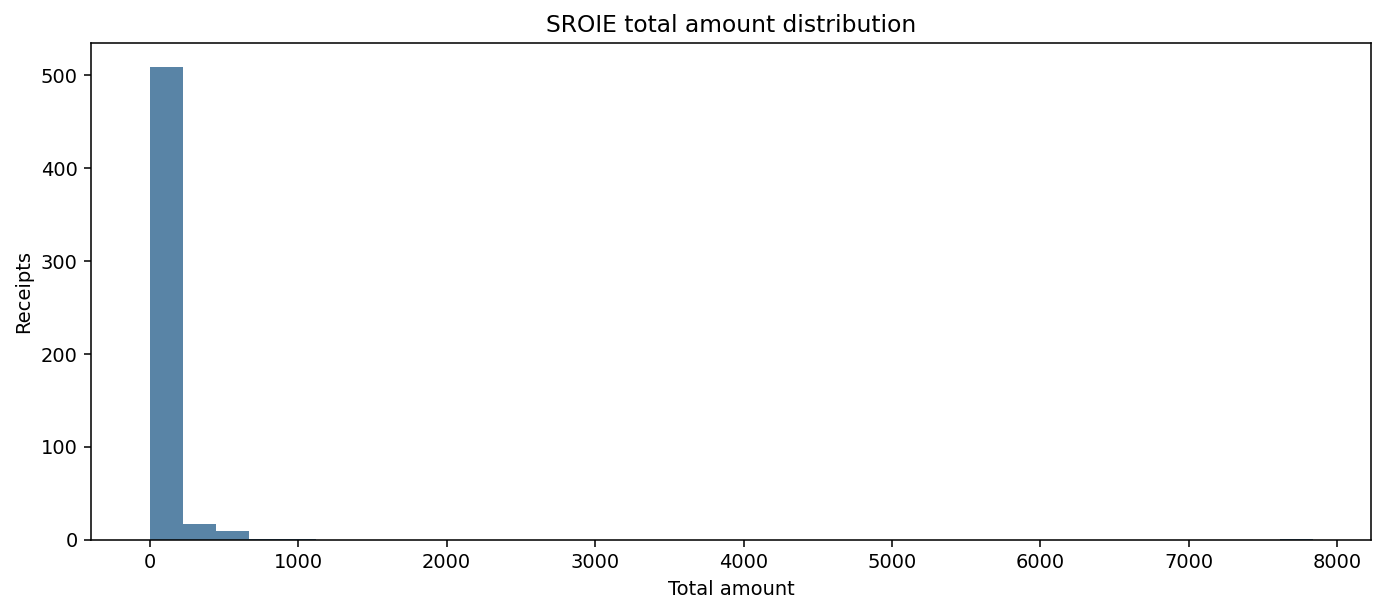

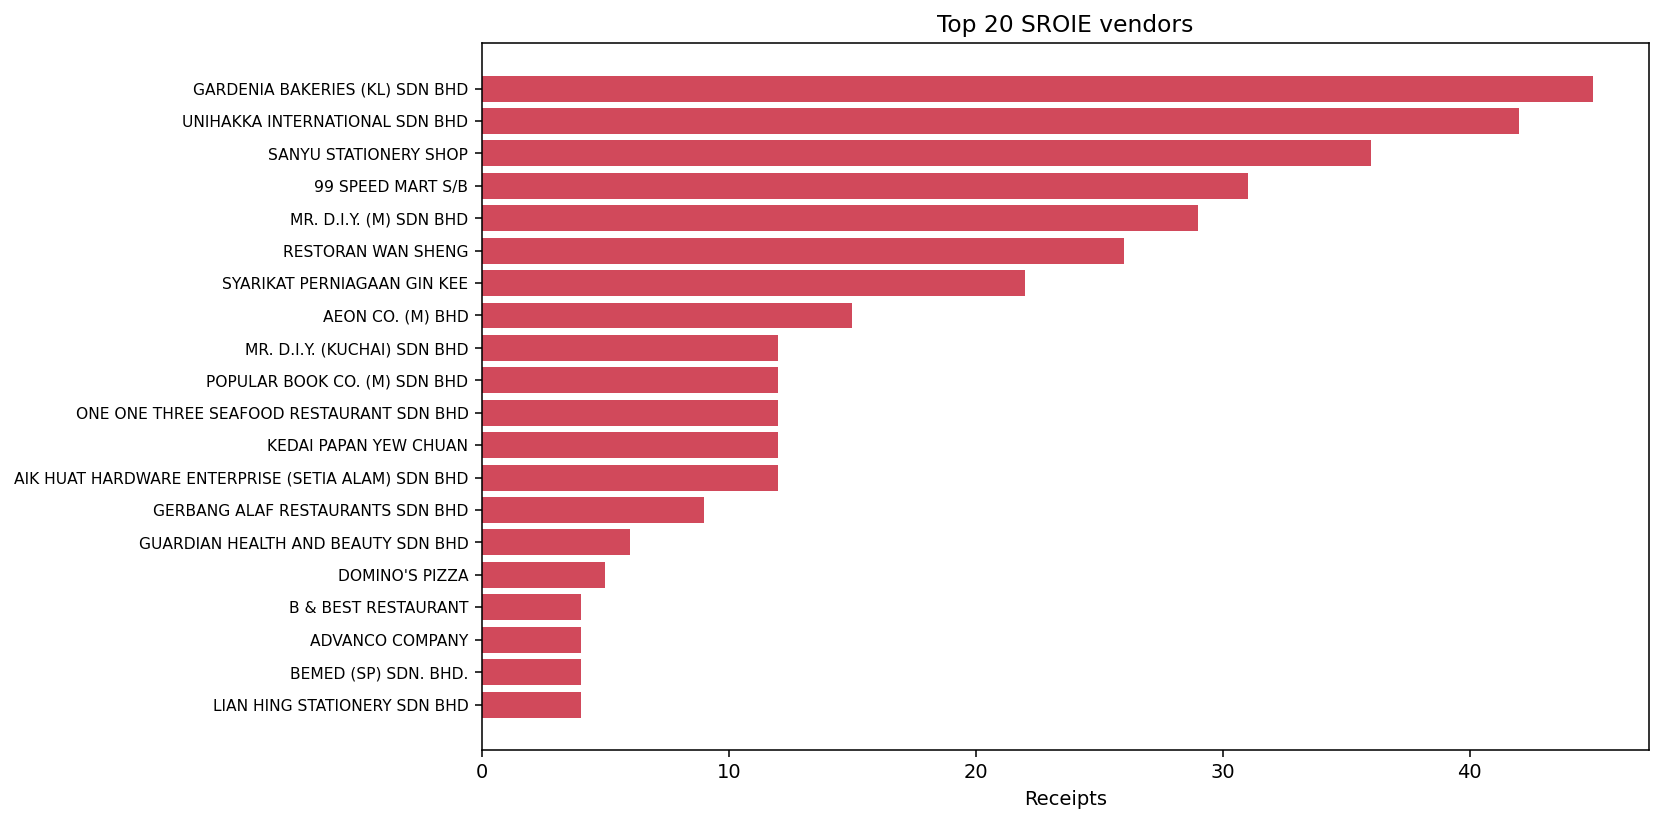

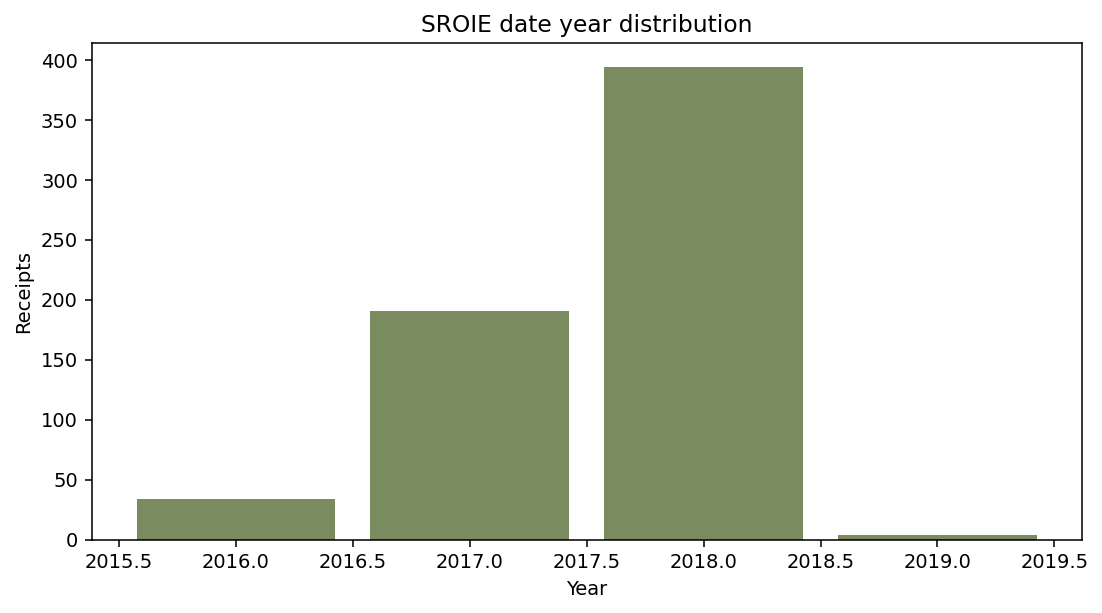

In [5]:
entities = []
for path in sorted(glob(os.path.join(SROIE_ENT_DIR, '*.txt'))):
    with open(path) as f:
        item = json.load(f)
    total_text = str(item.get('total', '')).replace(',', '').strip()
    total = float(total_text) if total_text else np.nan
    entities.append({
        'company': item.get('company', '').strip(),
        'date': item.get('date', '').strip(),
        'total': total,
    })

totals = np.array([row['total'] for row in entities if not np.isnan(row['total'])])
vendors = [row['company'] for row in entities if row['company']]
vendor_names, vendor_counts = np.unique(vendors, return_counts=True)
order = np.argsort(vendor_counts)[::-1][:20]
years = np.array([year_from_date(row['date']) for row in entities if year_from_date(row['date']) is not None])

print('SROIE entity files:', len(entities))
print('Unique vendors:', len(set(vendors)))
print('Mean total amount:', round(float(np.mean(totals)), 2))
print('Median total amount:', round(float(np.median(totals)), 2))
print('Year span:', int(np.min(years)), 'to', int(np.max(years)))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(totals, bins=35, color='#2f6690', alpha=0.8)
ax.set_title('SROIE total amount distribution')
ax.set_xlabel('Total amount')
ax.set_ylabel('Receipts')
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_total_amount_distribution.png'), dpi=140, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(np.arange(len(order)), vendor_counts[order], color='#d1495b')
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(vendor_names[order], fontsize=8)
ax.invert_yaxis()
ax.set_title('Top 20 SROIE vendors')
ax.set_xlabel('Receipts')
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_vendor_top20.png'), dpi=140, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(np.min(years) - 0.5, np.max(years) + 1.5, 1)
ax.hist(years, bins=bins, color='#7a8b5f', rwidth=0.85)
ax.set_title('SROIE date year distribution')
ax.set_xlabel('Year')
ax.set_ylabel('Receipts')
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_date_distribution.png'), dpi=140, bbox_inches='tight')
plt.show()


## 4. Cross-Source Comparison

This comparison highlights the visual and OCR differences between the real datasets and the local dummy set. It is a quick way to estimate how much domain shift the model stack should expect.


Key statistics by source
Source | Images | Mean WxH  | Mean size KB | Sampled OCR words
-------+--------+-----------+--------------+------------------
SROIE  | 626    | 1326x2356 | 553.5        | 114.5            
CORD   | 20     | 1025x1626 | 1648.2       | 48.4             
Dummy  | 20     | 200x100   | 0.3          | 0.0              


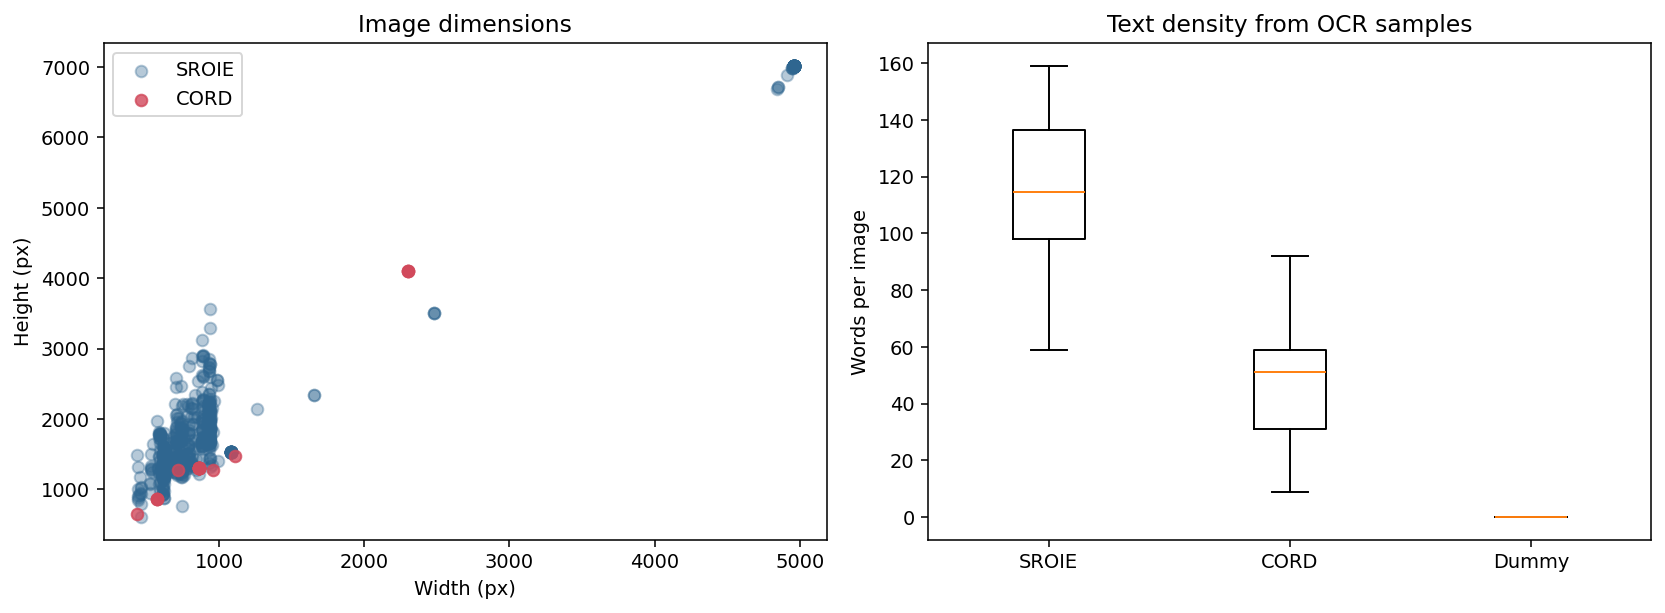

In [6]:
sroie_dims = np.array([Image.open(path).size for path in sroie_images])
cord_dims = np.array([Image.open(path).size for path in cord_images])
dummy_dims = np.array([Image.open(path).size for path in dummy_images])
dummy_word_counts = np.array([len(run_tesseract_tsv(path)['words']) for path in dummy_images[:5]])
sroie_word_counts = np.array([len(item['words']) for _, item in sroie_ocr])
cord_word_counts = np.array([len(item['words']) for _, item in cord_ocr])

print('Source | Images | Mean WxH | Mean size KB | Sampled OCR words')
print('SROIE |', len(sroie_images), '|', f'{int(np.mean(sroie_dims[:,0]))}x{int(np.mean(sroie_dims[:,1]))}', '|', round(float(np.mean(sroie_sizes)), 1), '|', round(float(np.mean(sroie_word_counts)), 1))
print('CORD  |', len(cord_images), '|', f'{int(np.mean(cord_dims[:,0]))}x{int(np.mean(cord_dims[:,1]))}', '|', round(float(np.mean(cord_sizes)), 1), '|', round(float(np.mean(cord_word_counts)), 1))
print('Dummy |', len(dummy_images), '|', f'{int(np.mean(dummy_dims[:,0]))}x{int(np.mean(dummy_dims[:,1]))}', '|', round(float(np.mean(dummy_sizes)), 1), '|', round(float(np.mean(dummy_word_counts)), 1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(sroie_dims[:, 0], sroie_dims[:, 1], alpha=0.35, label='SROIE', color='#2f6690')
ax[0].scatter(cord_dims[:, 0], cord_dims[:, 1], alpha=0.8, label='CORD', color='#d1495b')
ax[0].set_title('Image dimensions')
ax[0].set_xlabel('Width (px)')
ax[0].set_ylabel('Height (px)')
ax[0].legend()
ax[1].boxplot([sroie_word_counts, cord_word_counts, dummy_word_counts], tick_labels=['SROIE', 'CORD', 'Dummy'])
ax[1].set_title('Text density from OCR samples')
ax[1].set_ylabel('Words per image')
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_cross_source_comparison.png'), dpi=140, bbox_inches='tight')
plt.show()


## 5. Anomaly Landscape

Error Level Analysis (ELA) is used here as a lightweight visual tampering proxy. The distribution of ELA means helps identify sources or individual documents that look compression-inconsistent and deserve manual review.


Top ELA outliers
- CORD: cord_017.png -> mean ELA 2.566
- CORD: cord_011.png -> mean ELA 2.446
- CORD: cord_009.png -> mean ELA 2.071
- CORD: cord_012.png -> mean ELA 1.942
- CORD: cord_001.png -> mean ELA 1.888
- CORD: cord_014.png -> mean ELA 1.746
- SROIE: X00016469669.jpg -> mean ELA 1.709
- CORD: cord_010.png -> mean ELA 1.690
- CORD: cord_008.png -> mean ELA 1.665
- CORD: cord_006.png -> mean ELA 1.613


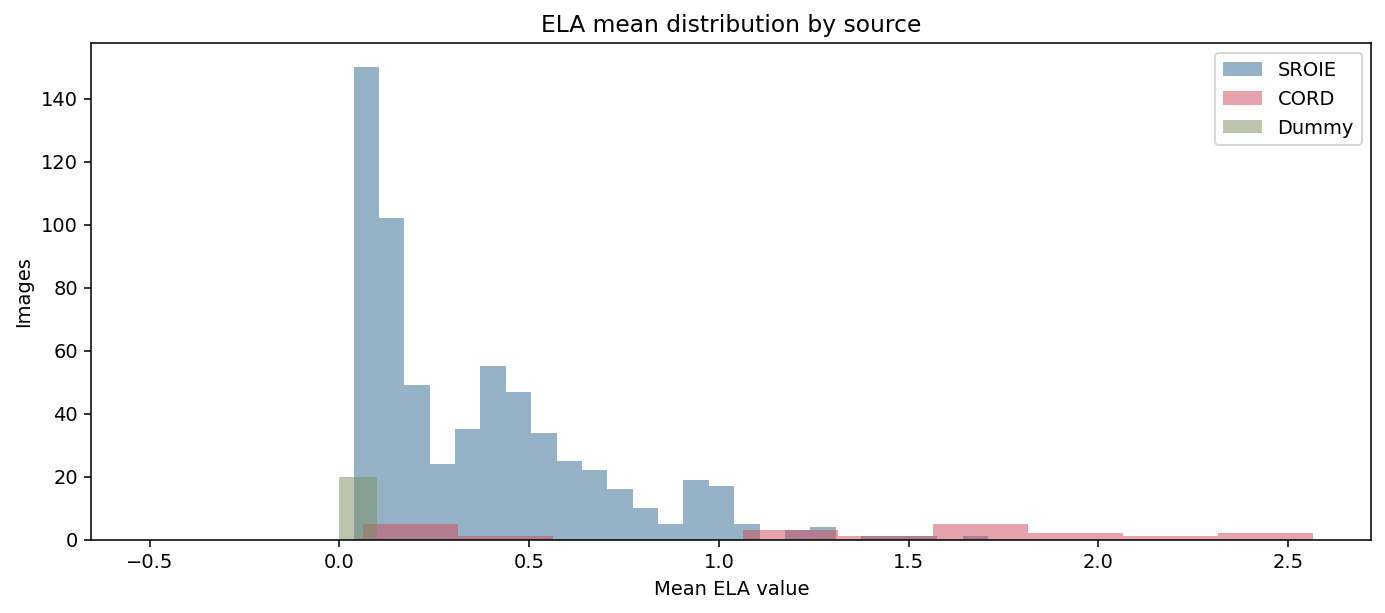

In [7]:
ela_records = []
for source_name, paths in [('SROIE', sroie_images), ('CORD', cord_images), ('Dummy', dummy_images)]:
    for path in paths:
        ela_records.append((source_name, os.path.basename(path), ela_mean(path)))

print('Top ELA outliers:')
for source_name, name, score in sorted(ela_records, key=lambda row: row[2], reverse=True)[:10]:
    print(source_name, name, round(float(score), 3))

fig, ax = plt.subplots(figsize=(10, 4.5))
for source_name, color, bins in [('SROIE', '#2f6690', 25), ('CORD', '#d1495b', 10), ('Dummy', '#7a8b5f', 10)]:
    values = [score for src, _, score in ela_records if src == source_name]
    ax.hist(values, bins=bins, alpha=0.5, label=source_name, color=color)
ax.set_title('ELA mean distribution by source')
ax.set_xlabel('Mean ELA value')
ax.set_ylabel('Images')
ax.legend()
fig.savefig(os.path.join(NOTEBOOK_DIR, '01_ela_distribution.png'), dpi=140, bbox_inches='tight')
plt.show()


## Notes

All plots are also saved as `.png` files in `notebooks/` for reuse outside Jupyter. The notebook references `/tmp/sroie` and `/tmp/cord_samples` directly and will show empty results if those datasets are not downloaded into those paths.
